# Gaussian-process regression: the marginal likelihood through a Cholesky factor

Fitting the hyperparameters of a Gaussian process means maximizing its marginal likelihood, which
is computed from a Cholesky factorization of the kernel matrix. Libraries usually differentiate it
with a hand-derived trace formula; here Scaly differentiates **through the generated Cholesky
factorization and triangular solves** — to first and second order — and the checks against the
formula come out at rounding level.

| Scaly feature | Where |
| --- | --- |
| dense `linalg.cholesky`, `solve_triangular`, `cho_solve` as generated loops | the likelihood and the predictions |
| `sc.gradient` and `sc.hessian` through those factorizations | the fit, and a Laplace approximation of the hyperparameter posterior |
| broadcasting arithmetic on `Expr` | the kernel matrix |

The script version is `examples/linalg/gaussian_process.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from scipy import optimize

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "gaussian_process"
N_TRAIN, N_TEST = 120, 300

## Data

Noisy samples of $f(x) = \sin(1.5x) + 0.3\cos(4x)$ at 120 random points in $[-4, 4]$, noise
standard deviation 0.1.

In [2]:
rng = np.random.default_rng(0)
x_train = np.sort(rng.uniform(-4, 4, N_TRAIN))
truth = lambda x: np.sin(1.5 * x) + 0.3 * np.cos(4 * x)  # noqa: E731
y_train = truth(x_train) + 0.1 * rng.standard_normal(N_TRAIN)

## Model and likelihood

A zero-mean GP with the squared-exponential kernel and Gaussian noise,
$k(x, x') = s_f^2 \exp\!\big(-\tfrac{(x - x')^2}{2\ell^2}\big)$, $K = k(X, X) + s_n^2 I$, has the
negative log marginal likelihood

$$
\mathrm{NLL}(\theta) = \tfrac12\, y^\top K^{-1} y + \sum_i \log L_{ii} + \tfrac n2 \log 2\pi, \qquad K = L L^\top,
$$

in $\theta = (\log\ell, \log s_f, \log s_n)$. At order 120 the generated Cholesky and triangular
solve are loops with triangular bounds (orders up to `sc.options(linalg=dict(dense_unroll=...))`, 8 by default,
are unrolled instead).

In [3]:
def kernel(xa, xb, length, scale):
  d = xa.reshape((xa.size, 1)) - xb.reshape((1, xb.size))
  return scale * scale * (-(d * d) / (2 * length * length)).exp()


def factor(theta, x):
  length, scale, noise = theta[0].exp(), theta[1].exp(), theta[2].exp()
  return linalg.cholesky(kernel(x, x, length, scale) + sc.const(np.eye(N_TRAIN)) * (noise * noise))


def nll(theta, x, y):
  chol = factor(theta, x)
  white = linalg.solve_triangular(chol, y)  # L^{-1} y
  log_det = sc.gather(chol, np.arange(N_TRAIN) * (N_TRAIN + 1)).log().sum()  # the diagonal of L
  return 0.5 * sc.sumsqr(white) + log_det + 0.5 * N_TRAIN * np.log(2 * np.pi)


@sc.function(3, N_TRAIN, N_TRAIN, output=sc.G("nll", "grad", "hess"))
def marginal_likelihood(theta, x, y):
  value = nll(theta, x, y)
  return value, sc.gradient(value, theta), sc.hessian(value, theta)


@sc.function(3, N_TRAIN, N_TRAIN)
def nll_value(theta, x, y):
  return nll(theta, x, y)

## Checking the derivatives

The classical gradient is $\partial\,\mathrm{NLL}/\partial\theta_j = \tfrac12 \operatorname{tr}\!\big((K^{-1} - \alpha\alpha^\top)\,\partial K/\partial\theta_j\big)$
with $\alpha = K^{-1}y$. Scaly's reverse mode through the factorization agrees with it; the
Hessian (forward-over-reverse through the same factorization) agrees with differences of the
gradient.

In [4]:
def trace_formula(theta):
  ell, sf, sn = np.exp(theta)
  d2 = (x_train[:, None] - x_train[None, :]) ** 2
  k_f = sf**2 * np.exp(-d2 / (2 * ell**2))
  k = k_f + sn**2 * np.eye(N_TRAIN)
  alpha = np.linalg.solve(k, y_train)
  inner = np.linalg.inv(k) - np.outer(alpha, alpha)
  return np.array([0.5 * np.sum(inner * dk) for dk in (k_f * d2 / ell**2, 2 * k_f, 2 * sn**2 * np.eye(N_TRAIN))])


theta0 = np.log([1.0, 1.0, 0.5])
_, grad, hess = marginal_likelihood(theta0, x_train, y_train)
eps = 1e-6
hess_fd = np.stack([(marginal_likelihood(theta0 + eps * e, x_train, y_train)[1] - marginal_likelihood(theta0 - eps * e, x_train, y_train)[1]) / (2 * eps) for e in np.eye(3)])
print("gradient, reverse mode through the Cholesky:", grad)
print("gradient, trace formula:                    ", trace_formula(theta0))
print(f"Hessian vs differences of the gradient: {np.abs(hess - hess_fd).max():.1e}")

gradient, reverse mode through the Cholesky: [ 3.46691322  1.611536   90.33474303]
gradient, trace formula:                     [ 3.46691322  1.611536   90.33474303]
Hessian vs differences of the gradient: 3.9e-08


## Fitting, and a Laplace approximation

L-BFGS on the NLL and its gradient. At the optimum the Hessian $H$ of the NLL in $\theta$ gives a
Gaussian (Laplace) approximation of the hyperparameters' posterior under a flat prior,
$\theta \sim \mathcal N(\hat\theta, H^{-1})$.

In [5]:
fit = optimize.minimize(lambda th: marginal_likelihood(th, x_train, y_train)[:2], theta0, jac=True, method="L-BFGS-B")
_, grad_opt, hess_opt = marginal_likelihood(fit.x, x_train, y_train)
cov = np.linalg.inv(hess_opt)
ell, sf, sn = np.exp(fit.x)
print(f"{fit.nfev} evaluations: l = {ell:.3f}, sf = {sf:.3f}, sn = {sn:.3f} (true noise 0.1); |grad| = {np.abs(grad_opt).max():.1e}")
print("posterior std of (log l, log sf, log sn):", np.sqrt(np.diag(cov)))

18 evaluations: l = 0.624, sf = 0.793, sn = 0.101 (true noise 0.1); |grad| = 5.1e-05
posterior std of (log l, log sf, log sn): [0.1005754  0.24713739 0.06973625]


## The likelihood landscape

The NLL over $(\ell, s_n)$ with $s_f$ at its fitted value, the optimum, and the 1- and 2-standard-
deviation ellipses of the Laplace approximation (projected on the same plane).

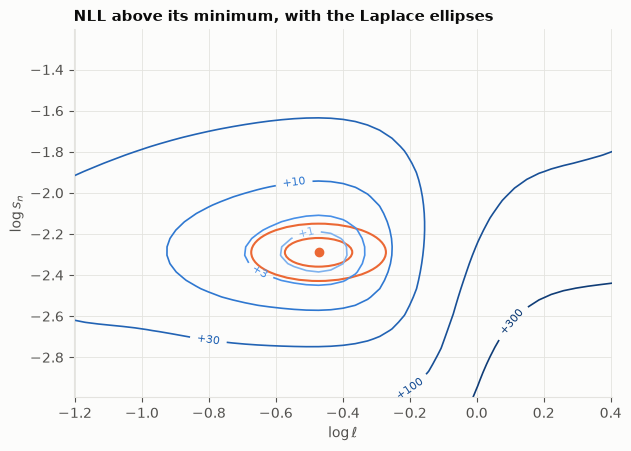

In [6]:
ells, sns = np.linspace(np.log(0.3), np.log(1.5), 45), np.linspace(np.log(0.05), np.log(0.3), 45)
grid = np.array([[nll_value(np.array([a, fit.x[1], b]), x_train, y_train) for a in ells] for b in sns])  # values only: no derivatives needed
fig, ax = plt.subplots(figsize=(6.2, 4.4))
levels = fit.fun + np.array([1, 3, 10, 30, 100, 300])
shades = [plotstyle.BLUES(v) for v in np.linspace(0.35, 0.95, len(levels))]
contours = ax.contour(ells, sns, grid, levels=levels, colors=shades, linewidths=1.2)
ax.clabel(contours, fmt=lambda v: f"+{v - fit.fun:.0f}", fontsize=8)
sub = cov[np.ix_([0, 2], [0, 2])]
vals, vecs = np.linalg.eigh(sub)
for k_sigma in (1, 2):
  ax.add_patch(Ellipse((fit.x[0], fit.x[2]), 2 * k_sigma * np.sqrt(vals[1]), 2 * k_sigma * np.sqrt(vals[0]),
                       angle=np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1])), fill=False, color=plotstyle.ORANGE, lw=1.5))
ax.plot(fit.x[0], fit.x[2], "o", color=plotstyle.ORANGE, ms=6)
ax.set_xlabel(r"$\log \ell$")
ax.set_ylabel(r"$\log s_n$")
ax.set_title("NLL above its minimum, with the Laplace ellipses")
plt.show()

## Predictions

The predictive mean $k_*^\top K^{-1} y$ and variance $k(x_*, x_*) - \lVert L^{-1} k_*\rVert^2$ on a
test grid are a second generated function — the part one would deploy. The band is
$\pm 2$ predictive standard deviations of the latent function; it widens outside the data.

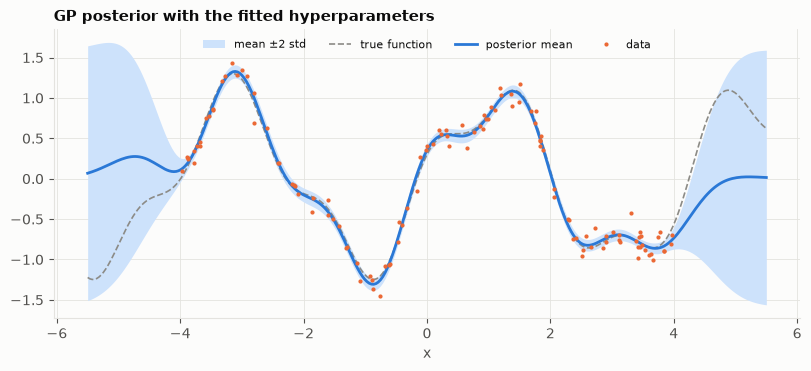

RMSE of the mean on [-4, 4]: 0.039


In [7]:
@sc.function(3, N_TRAIN, N_TRAIN, N_TEST, output=sc.G("mean", "var"))
def predict(theta, x, y, x_test):
  length, scale = theta[0].exp(), theta[1].exp()
  chol = factor(theta, x)
  k_star = kernel(x, x_test, length, scale)
  v = linalg.solve_triangular(chol, k_star)
  return k_star.T @ linalg.cho_solve(chol, y), scale * scale - (v * v).T @ sc.const(np.ones(N_TRAIN))


x_test = np.linspace(-5.5, 5.5, N_TEST)
mean, var = predict(fit.x, x_train, y_train, x_test)
std = np.sqrt(np.maximum(var, 0))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.fill_between(x_test, mean - 2 * std, mean + 2 * std, color="#cde2fb", lw=0, label=r"mean $\pm 2$ std")
ax.plot(x_test, truth(x_test), color=plotstyle.NEUTRAL, lw=1.2, ls="--", label="true function")
ax.plot(x_test, mean, color=plotstyle.BLUE, lw=2, label="posterior mean")
ax.plot(x_train, y_train, ".", color=plotstyle.ORANGE, ms=4, label="data")
ax.set_xlabel("x")
ax.set_title("GP posterior with the fitted hyperparameters")
ax.legend(loc="upper center", fontsize=8, ncol=4)
plt.show()
inside = np.abs(x_test) < 4
print(f"RMSE of the mean on [-4, 4]: {np.sqrt(np.mean((mean[inside] - truth(x_test[inside])) ** 2)):.3f}")

In [8]:
for fn in (marginal_likelihood, predict):
  module = write_module(fn, GENERATED)
  print(f"{module.source_name}: {len(module.source.splitlines())} lines, workspace {module.workspace_size} doubles")

marginal_likelihood.c: 1064 lines, workspace 777600 doubles
predict.c: 193 lines, workspace 86400 doubles
